# Computation of ensemble growth rate kymographs for wide-trenches microfluidics

__Steps__:
1. Download zip folder for a given experiment/condition and extract the data. In this example, we will process data from 'CJW7753_PR-39_4uM_wide-trench.zip'
2. After running 'import_processing_code_wide-trench.py' and 'post_processing_curation_code_wide-trench.py', step 3, import the curated dataframes and pool trajectories across multiple trenches to build gorwth rate kymographs

__Requirements on how to run__:
- This notebook assumes the OmniSegger-processed extracted file data folder, here 'CJW7753_PR-39_4uM_wide-trench', lives in the same folder as the notebook, and output dataframes have already being generated and curated (step 3)

__Code underlying data and figures__:
- Single-cell data in wide-trenches microfluidics, strain CJW7753, for computing growth rate ensemble kymographs
- Figures 5D-F and 5I, S8A-B

### Import curated cell features dataframes

Run time: < 10 min

In [12]:
# -*- coding: utf-8 -*-
"""
Code for single-cell analysis for images processed by SuperSegger-Omnipose (wide-trench geometry):
1) Imports cell arrays output from SuperSegger, containing cell masks, cropped channels, cell_ids, bounding boxes (https://github.com/wiggins-lab/SuperSegger/wiki/The-cell-data-files)
2) Apply background subtraction (Adapted from Papagiannakis et al., eLife, 2025) to fluorescence channels (full images)
3) Goes through each cell file output from Supersegger, extracts cell info, coordinates of the bounding box (cropped cell image), computes statistics using Omnipose masks,
    computes masks for fluorescence channels (e.g. nucleoid, ribosomes), correlation (SCF) between the different channels

Output:
- Dictionary with cropped images for each cell, at each frame, for all channels (phase, fluor1, fluor2) and corresponding masks
- Dictionary of cell information, e.g. birth, death, division, as estimated by SuperSegger
- Dataframe of cell features, e.g. area, time, mean fluorescences, correlations. Only 'static' features are estimated here
    based on the single frame - kinetic parameters, e.g. growth rate, are computed later on.

@author: alessio fragasso
Tue Jun 20 22:09:45 2023
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy import ndimage as ndi 
from pathlib import Path
import glob
import warnings #(used by warnings.filterwarnings('ignore'))

fr = 1
px_size = 0.065841

experiment_path = "CJW7753_PR-39_4uM_wide-trench"     # extracted archive folder, next to the notebook
exp_name = experiment_path
AMP_name = "PR-39_4uM"
AMP_label = "PR-39, 4uM"

# --- load curated trench dataframe(s) from local output_tr_filtered ---
df_all = pd.DataFrame()
for f in sorted(glob.glob(experiment_path + '/output_2/*cell_features_df_trenches*.pkl')):
    sub = pd.read_pickle(f)
    if len(sub):
        df_all = pd.concat([df_all, sub])
df_all['AMP'] = AMP_name


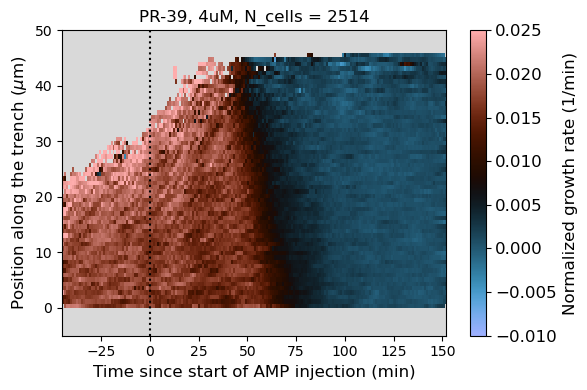

In [16]:

'''Plot kymograph'''
prune = True
base_dir = Path(experiment_path) / 'output_growth_rate_kymo'
plot_dir = base_dir / 'kymo_plots'
df_dir = base_dir / 'kymo_dfs'
plot_dir.mkdir(parents=True, exist_ok=True)
df_dir.mkdir(parents=True, exist_ok=True)

df_tr = df_all.copy()

df_tr['time_min_offs'] = df_tr['time_min'] - fr * df_tr['fr_inj']
df_tr['rcm_x_offset_neg'] = -df_tr['rcm_x_offset']

'''Spatial binning along trench axis'''
dx = 12
rcm_min_global = df_tr['rcm_x_offset_neg'].min()
rcm_max_global = df_tr['rcm_x_offset_neg'].max()
start = np.floor(rcm_min_global / dx) * dx
stop = np.ceil(rcm_max_global / dx) * dx
rcm_edges = np.arange(start, stop + dx, dx)

df_tr['rcm_bin'] = pd.cut(df_tr['rcm_x_offset_neg'], bins=rcm_edges, include_lowest=True, right=False)
rcm_centers = (rcm_edges[:-1] + rcm_edges[1:]) / 2
df_tr['rcm_center'] = rcm_centers[df_tr['rcm_bin'].cat.codes]

df_kymo_raw = (
    df_tr.groupby(['time_min_offs', 'rcm_bin'], observed=True)['norm_gr_savgol']
    .median().reset_index()
)
Z_raw = (
    df_kymo_raw.pivot(index='time_min_offs', columns='rcm_bin', values='norm_gr_savgol')
    .sort_index(axis=0).sort_index(axis=1)
)
occupied = Z_raw.notna().to_numpy()

'''Prune isolated pixels'''
if prune:
    dt, dy = 1, 2
    kernel = np.ones((2*dt + 1, 2*dy + 1), dtype=int)
    kernel[:, dy] = 0
    min_neighbors, n_iter = 5, 5
    keep_pixels = occupied.copy()
    for _ in range(n_iter):
        neighbor_count = ndi.convolve(keep_pixels.astype(int), kernel, mode='constant', cval=0)
        new_keep_pixels = keep_pixels & (neighbor_count >= min_neighbors)
        if np.array_equal(new_keep_pixels, keep_pixels):
            break
        keep_pixels = new_keep_pixels
    Z = Z_raw.where(keep_pixels)
    keep_rc, keep_cc = np.where(keep_pixels)
    keep_pairs = pd.MultiIndex.from_arrays(
        [Z_raw.index.to_numpy()[keep_rc], Z_raw.columns.to_numpy()[keep_cc]],
        names=['time_min_offs', 'rcm_bin'])
    df_pairs = pd.MultiIndex.from_frame(df_tr[['time_min_offs', 'rcm_bin']])
    df_tr_surv = df_tr[df_pairs.isin(keep_pairs)].copy()
else:
    Z = Z_raw.copy()
    df_tr_surv = df_tr.copy()

t = Z.index.to_numpy()
Z_mat = Z.to_numpy()
N_cells_final = df_tr_surv['cell_id'].nunique()
# N_trenches = int(np.nansum(df_tr_surv['N_trenches'].unique()))

'''Plot kymograph'''
vmin, vmax = -0.01, 0.025
norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap('berlin')                      # matplotlib >=3.10: cm.get_cmap was removed

y0_um = 0.0
y1_um = (rcm_edges[-1] - rcm_edges[0]) * px_size

fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor((0.85, 0.85, 0.85))
im = ax.imshow(Z_mat.T, origin='lower', aspect='auto', cmap=cmap, norm=norm,
               extent=[t.min(), t.max(), y0_um, y1_um], interpolation='nearest')
ax.set_xlabel('Time since start of AMP injection (min)', fontsize=12)
ax.set_ylabel(r'Position along the trench ($\mu$m)', fontsize=12)
ax.set_title(f'{AMP_label}, N_cells = {N_cells_final}')
cb = fig.colorbar(im, ax=ax)
cb.set_label('Normalized growth rate (1/min)', fontsize=12)
cb.ax.yaxis.set_tick_params(labelsize=12)
ax.axvline(x=0, linestyle=':', c='black')
ax.set_ylim(-5, 50)
plt.tight_layout()

safe_label = AMP_label.replace(',', '').replace(' ', '_').replace('/', '-')
plt.savefig(plot_dir / f'{safe_label}.pdf', format='pdf')
plt.show()